# 1. Import Library

In [17]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install pySastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.9 MB/s eta 0:00:00


- `pandas` (pd) : Digunakan untuk analisis dan manipulasi data, terutama dengan data tabular seperti tabel.
- `numpu` (np) : Digunakan untuk operasi numerik terutama dengan array dan matriks.
- `matplotlib.pyploy` (plt) : Pustaka dasar untuk membuat visualisasi statis, interaktif dan animasi di Python.
- `seaborn` (sns) : Pustaka untuk visualisasi data statistik yang dibangun di atas Matplotlib, menyediakan antarmuka tingkat tinggi untuk menggambar grafik yang menarik dan informatif.
- `datetime` (dt) : Dapat digunakan untuk tanggal dan waktu.
- `re` : Menyediakan operasi ekspresi reguler untuk percobaan pola dalam string.
- `string` : Berisi konstanta string umum dan fungsi untuk memproses string.
- `nltk.tokenize.word_tokenize` : Digunakan untuk memecah teks menjadi kata-kata (tokenisasi).
- `nltk.corpus.stopwords` : Menyediakan daftar kata umum (stop words) yang biasanya diabaikan dalam pemrosesan teks.
- `Sastrawi.Stemmer.StemmerFactory` : Digunakan untuk melakukan stemming pada kata-kata bahasa Indonesia (mengubah kata berimbuhan menjadi kata dasar).
- `Sastrawi.StopWordRemover.StopWordRemoverFactory` : Digunakan untuk menghapus stop words dalam teks bahasa Indonesia.
`wordcloud` : Digunakan untuk membuat visualisasi 'word cloud', di mana kata-kata ditampilkan dengan ukuran yang bervariasi sesuai frekuensinya dalam teks.

In [18]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

- `import nltk` : Mengimpor pustaka Natural Language Toolkit (NLTK), yang merupakan pustaka populer untuk pemrosesan bahasa alami (NLP) di Python.
- `nltk.download('punkt')` : Mengunduh model 'punkt' dari NLTK. Model ini sangat penting untuk tokenisasi, yaitu proses memecah teks menjadi unit-unit yang lebih kecil seperti kalimat atau kata.
- `nltk.download('punkt_tab')` : Mengunduh model 'punkt_tab' : Variasi atau tambahan untuk model tokenisasi 'punkt'.
- `nltk.download('stopword')` : Mengunduh daftar kata-kata penghenti (stopwords) dalam berbagai bahasa dari NLTK. Stopwords adalah kata-kata umum (seperti 'dan', 'yang', 'di') yang seringkali tidak relevan untuk analisis teks dan biasanya dihapus sebelum pemrosesan lebih lanjut.

# 2. Load Dataset

In [19]:
import pandas as pd
df = pd.read_csv('ulasan_gojek.csv')

In [20]:
jumlah_ulasan, jumlah_kolom = df.shape

print(jumlah_ulasan)
print(jumlah_kolom)

12000
1


Pada dataset ulasan gojek terdiri dari 12.000 baris ulasan dan 1 kolom.

In [21]:
df.head()

,Review
0,"Aplikasi gojek ini lama-lama bikin gak nyaman,..."
1,Saat saya melakukan pemesanan yang tidak di se...
2,"pengunaan transportasi oke,tapi saat menunggu ..."
3,Aplikasi ini sangat membantu untuk bepergian d...
4,saya membeli minuman dari aplikasi ini dengan ...


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  12000 non-null  object
dtypes: object(1)
memory usage: 93.9+ KB


DataFrame terdiri dari 12.000 ulasan yang disimpan dalam satu kolom bernama 'Review', di mana setiap ulasan adalah teks dan tidak ada data yang hilang atau *missing values*

In [23]:
df_clean = df.dropna()

In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  12000 non-null  object
dtypes: object(1)
memory usage: 93.9+ KB


In [25]:
df_clean = df_clean.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = df_clean.shape

# 3. Pre-processing Text

In [26]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

def casefoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy","wkwk","wkwkwk", "mah"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(words):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    stemmed_words = [stemmer.stem(word) for word in words]

    return stemmed_words

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

- `cleaningText(text)` : bertugas membersihkan teks dari berbagai elemen yang tidak diinginkan seperti mention, hastag, indikator retweet, URL, angka, dan karakter non-alfanumerik lainnya. Selain itu, fungsi ini juga menghapus karakter *newlinw*, tanda baca, dan spasi di awal atau akhir teks.
- `casefoldingText(text)` : Fungsi ini melakukan casefolding pada teks, yaitu mengubah semua huruf dalam teks menjadi huruf kecil (lowercase). Tahap ini dilakukan untuk memastikan bahwa kata yang sama dengan kapitalisasi berbeda diperlakukan sebagai kata yang sama dalam analisis teks.

In [27]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget","gak": "tidak","gk": "tidak",
"indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know",
"ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan",
"ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi",
"aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang",
"ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi",
"bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan",
"beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh",
"blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga",
"bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong",
"buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren",
"calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat",
"cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong",
"cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall",
"cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik",
"dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat",
"dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana",
"drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya",
"emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi",
"gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja",
"gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol",
"githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa",
"gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he",
"helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah",
"humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja",
"jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar",
"jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan",
"kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya",
"kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau",
"kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau",
"klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya",
"komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim",
"kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara",
"latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan",
"lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu",
"lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo","vermuk": "verifikasi muka",
"mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali",
"mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa",
"mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional",
"muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana",
"napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri",
"ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan",
"ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis",
"ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara",
"ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing",
"ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu",
"ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan",
"pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri","bobrok":"tidak layak",
"pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah",
"perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "memesan": "pesan"}

def fix_slangwords(text):
    words = text.split()
    fix_words = []

    for word in words:
        if word.lower() in slangwords:
            fix_words.append(slangwords[word.lower()])
        else:
            fix_words.append(word)

    fix_text = ' '.join(fix_words)
    return fix_text

In [28]:
df_clean

,Review
0,"Aplikasi gojek ini lama-lama bikin gak nyaman,..."
1,Saat saya melakukan pemesanan yang tidak di se...
2,"pengunaan transportasi oke,tapi saat menunggu ..."
3,Aplikasi ini sangat membantu untuk bepergian d...
4,saya membeli minuman dari aplikasi ini dengan ...
...,...
11995,"Gojek eror terus, sering sekali dapat driver r..."
11996,"Mohon kedepan nya di tambahin fitur chat,jadi ..."
11997,"Layanan gojek mah oke bgt, tapi paylater di bl..."
11998,"Kecewa sama sistem gofood, kesalahan ada pada ..."


In [29]:
df_clean['text_clean'] = df_clean['Review'].apply(cleaningText)

In [30]:
df_clean['text_casefoldingText'] = df_clean['text_clean'].apply(casefoldingText)

In [31]:
df_clean['text_slangwords'] = df_clean['text_casefoldingText'].apply(fix_slangwords)

In [32]:
df_clean['text_tokenizingText'] = df_clean['text_slangwords'].apply(tokenizingText)

In [33]:
df_clean['text_stopword'] = df_clean['text_tokenizingText'].apply(filteringText)

In [34]:
df_clean['text_stemming'] = df_clean['text_stopword'].apply(stemmingText)

In [35]:
df_clean['text_final'] = df_clean['text_stemming'].apply(toSentence)

In [36]:
df_clean.head()

,Review,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_stemming,text_final
0,"Aplikasi gojek ini lama-lama bikin gak nyaman,...",Aplikasi gojek ini lamalama bikin gak nyamanud...,aplikasi gojek ini lamalama bikin gak nyamanud...,aplikasi gojek ini lamalama bikin tidak nyaman...,"[aplikasi, gojek, ini, lamalama, bikin, tidak,...","[aplikasi, gojek, lamalama, bikin, nyamanudah,...","[aplikasi, gojek, lamalama, bikin, nyamanudah,...",aplikasi gojek lamalama bikin nyamanudah vouch...
1,Saat saya melakukan pemesanan yang tidak di se...,Saat saya melakukan pemesanan yang tidak di se...,saat saya melakukan pemesanan yang tidak di se...,saat saya melakukan pemesanan yang tidak di se...,"[saat, saya, melakukan, pemesanan, yang, tidak...","[pemesanan, sengaja, membatalkan, cancel, pesa...","[mesan, sengaja, batal, cancel, pesan, tekan, ...",mesan sengaja batal cancel pesan tekan tombol ...
2,"pengunaan transportasi oke,tapi saat menunggu ...",pengunaan transportasi oketapi saat menunggu d...,pengunaan transportasi oketapi saat menunggu d...,pengunaan transportasi oketapi saat menunggu d...,"[pengunaan, transportasi, oketapi, saat, menun...","[pengunaan, transportasi, oketapi, menunggu, h...","[pengunaan, transportasi, oketapi, tunggu, har...",pengunaan transportasi oketapi tunggu harga st...
3,Aplikasi ini sangat membantu untuk bepergian d...,Aplikasi ini sangat membantu untuk bepergian d...,aplikasi ini sangat membantu untuk bepergian d...,aplikasi ini sangat membantu untuk bepergian d...,"[aplikasi, ini, sangat, membantu, untuk, beper...","[aplikasi, membantu, bepergian, pesan, makanan...","[aplikasi, bantu, pergi, pesan, makan, cepat, ...",aplikasi bantu pergi pesan makan cepat drivern...
4,saya membeli minuman dari aplikasi ini dengan ...,saya membeli minuman dari aplikasi ini dengan ...,saya membeli minuman dari aplikasi ini dengan ...,saya membeli minuman dari aplikasi ini dengan ...,"[saya, membeli, minuman, dari, aplikasi, ini, ...","[membeli, minuman, aplikasi, harga, mahal, lup...","[beli, minum, aplikasi, harga, mahal, lupa, vo...",beli minum aplikasi harga mahal lupa voucher h...


In [37]:
df_clean.to_csv('clean_data_ulasan.csv', index=False)

# 4. Load Dataset setelah Pre-processing Text

In [38]:
import pandas as pd
df_clean = pd.read_csv('clean_data_ulasan.csv')

In [39]:
jumlah_ulasan, jumlah_kolom = df_clean.shape

print(jumlah_ulasan)
print(jumlah_kolom)

11995
8


- Setelah semua langkah pre-processing text selesai dilakukan dan data tersebut disimpan ke dalam file `clean_data_ulasan.csv` langkah ini bertujuan untuk kembali memuat data yang sudah bersih tersebut ke dalam DataFrame baru.
- Menampilkan jumlah baris dan kolom yang sudah bersih yaitu sebanyak 11.995 baris dan 8 kolom.

# 5. Pelabelan Data

In [40]:
import csv
import requests
from io import StringIO

lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")


lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [41]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text.split():
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score += lexicon_negative[word]

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [42]:
results = df_clean['text_final'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df_clean['polarity_score'] = results[0]
df_clean['polarity'] = results[1]
print(df_clean['polarity'].value_counts())

polarity
positive    7794
negative    3693
neutral      508
Name: count, dtype: int64


- Bagian ini berfungsi untuk memberikan label sentimen yaitu positif, negatif, dan netral. Pada setiap ulasan yang telah dibersihkan dan diproses. Dan proses ini dilakukan menggunakan pendekatan berbasis leksikon.
- Pemuatan kamus leksikon terdiri dari kata-kata positif dan kata-kata negatif. Kamus ini menjadi dasar untuk menilai sentimen setiap kata.
- Kemudian ditampilkan jumlah ulasan untuk setiap kategori sentimen untuk memberikan gambaran umum tentang persebaran sentimen dalam dataset.

# 6. Eksplorasi Data

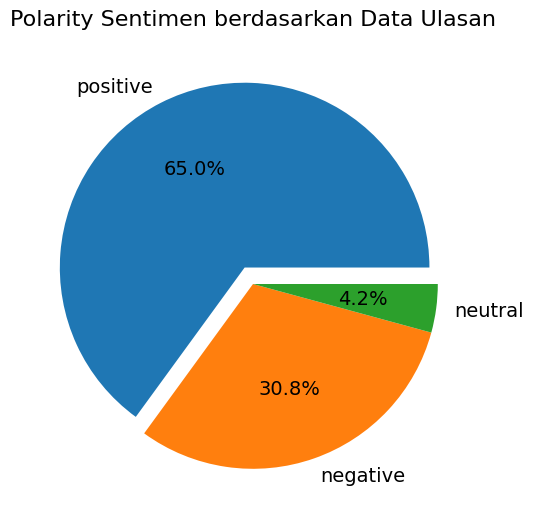

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in df_clean['polarity'].value_counts()]
labels = list(df_clean['polarity'].value_counts().index)
explode = [0.1] + [0] * (len(sizes) - 1)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Polarity Sentimen berdasarkan Data Ulasan', fontsize=16, pad=20)
plt.show()

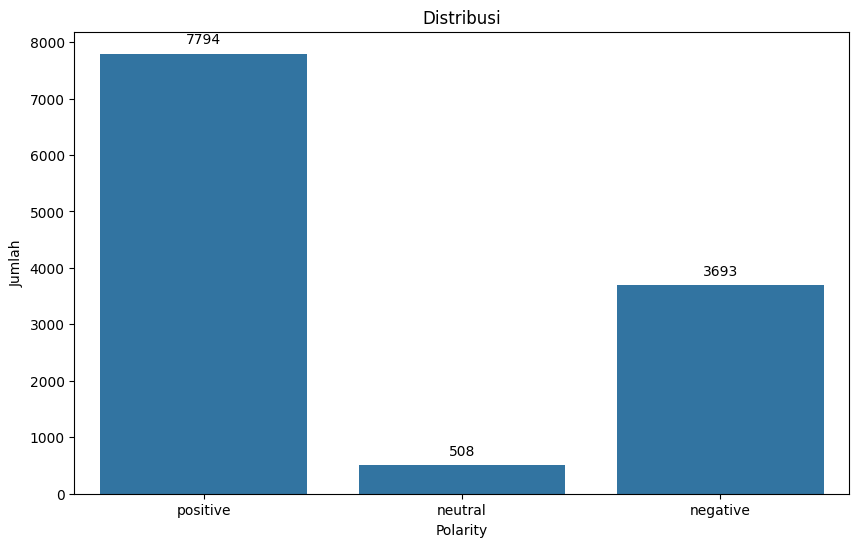

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=df_clean)
plt.title('Distribusi')
plt.xlabel('Polarity')
plt.ylabel('Jumlah')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

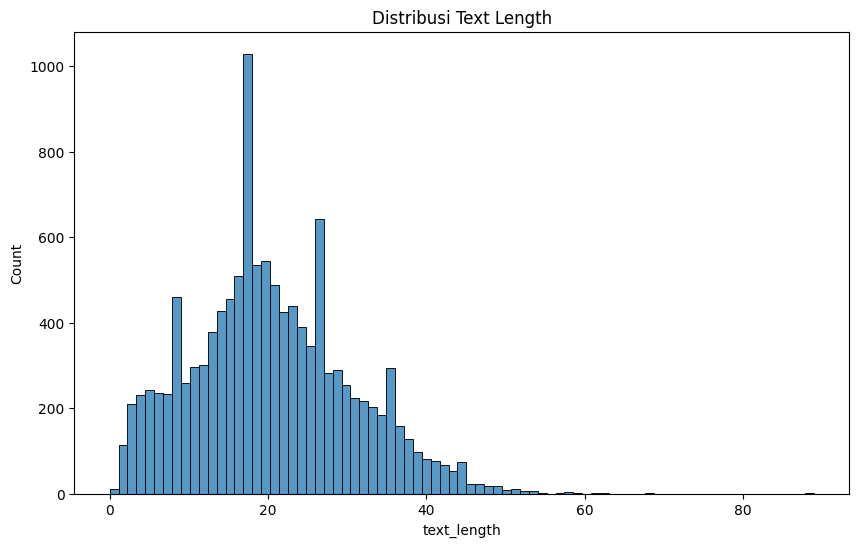

In [45]:
plt.figure(figsize=(10, 6))

df_clean['text_length'] = df_clean['text_final'].apply(lambda x: len(x.split()))
sns.histplot(df_clean['text_length'])
plt.title('Distribusi Text Length')
plt.show()

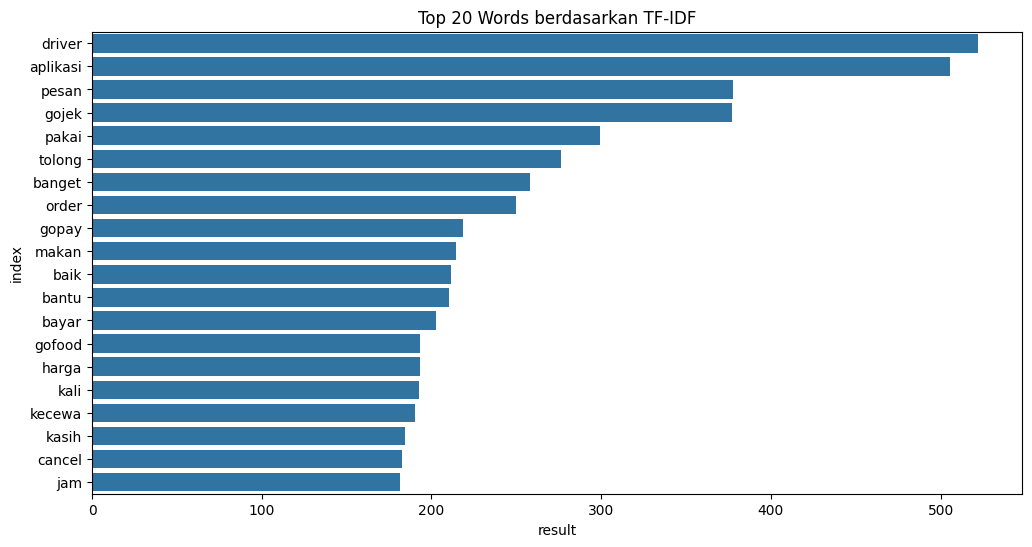

In [46]:
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df_clean['text_final'])
df_tfidf = pd.DataFrame(x.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf = df_tfidf.sum().reset_index(name='result')
df_tfidf = df_tfidf.sort_values('result', ascending=False).head(20)
sns.barplot(x='result', y='index', data=df_tfidf)
plt.title('Top 20 Words berdasarkan TF-IDF')
plt.show()

# 7. Word Cloud

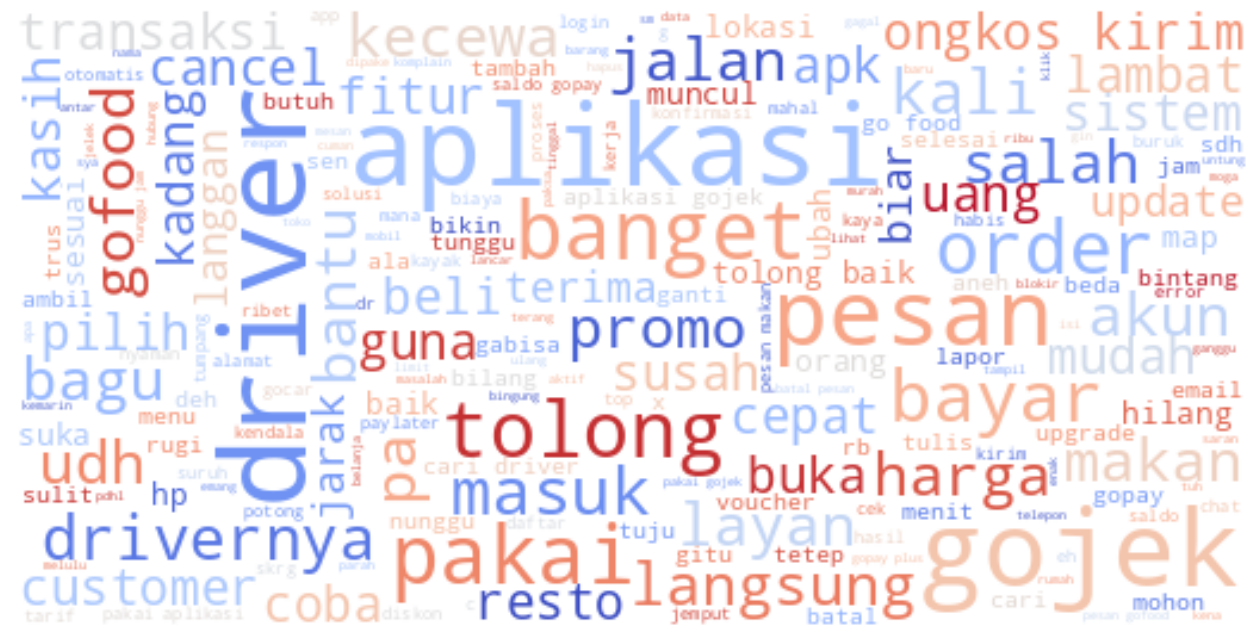

In [47]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

Positive_msg_text = 'positive'.join(df_clean['text_final'])

Positive_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Positive_msg_text)

plt.figure(figsize=(16,10))
plt.imshow(Positive_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Wordcloud Sentimen Positif :
- Kata-kata yang paling menonjol cenderung mencerminkan pengalaman positif pengguna, seperti 'aplikasi', 'gojek', 'bantu', 'baik', 'layan', 'cepat', dan 'pesan'. Ini menunjukkan bahwa pengguna menghargai kemudahan, kecepatan, dan layanan diberikan oleh aplikasi Gojek.

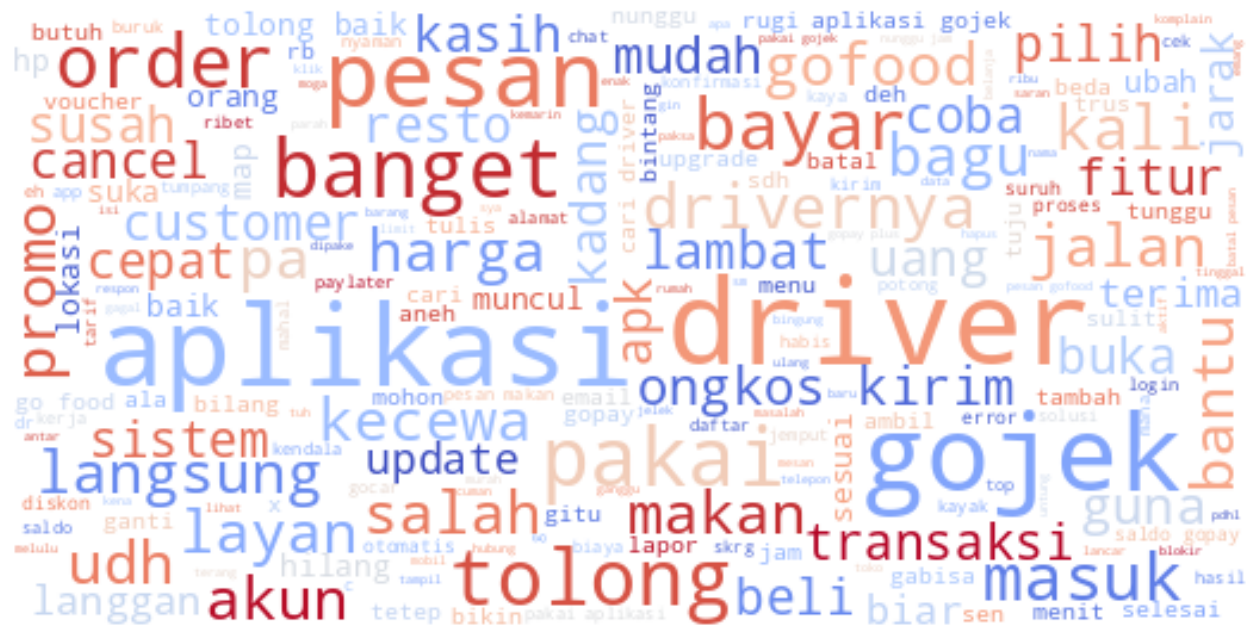

In [48]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

Negative_msg_text = 'negative'.join(df_clean['text_final'])

Negative_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Negative_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(Negative_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Wordcloud Sentimen Negatif :      
- Untuk sentimen negatif, kata-kata yang sering muncul adalah 'tidak', 'driver', 'salah', 'mahal', 'cancel', 'masalah', dan 'lama'. Ini mengidentifikasikan masalah seperti driver yang kurang memuaskan, biaya yang dirasa mahal, pembatalan pesanan, dan masalah terkait waktu layanan.

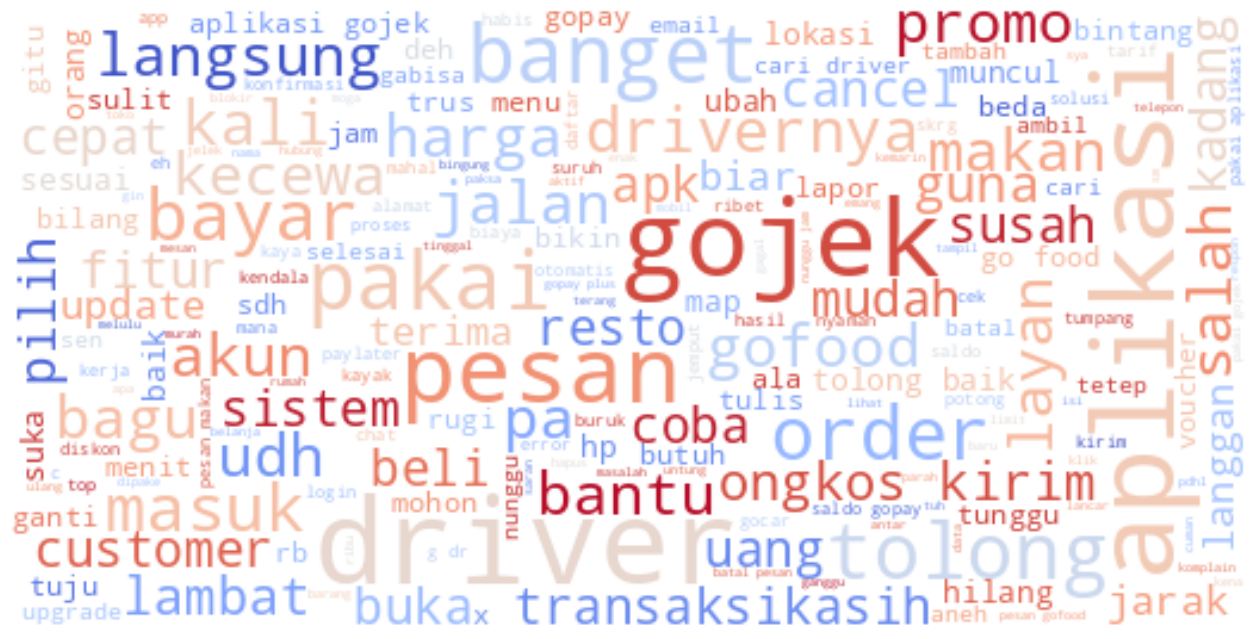

In [49]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

Neutral_msg_text = 'neutral'.join(df_clean['text_final'])

Neutral_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Neutral_msg_text)

plt.figure(figsize=(16,10))
plt.imshow(Neutral_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Worldcloud Sentimen Netral :     
- Wordcloud netral memiliki kata-kata sepeti 'tidak', 'aplikasi', 'pakai', 'gojek', dan 'mungkin'. Ini menunjukkan ulasan yang kurang spesifik dalam menyatakan kepuasan atau ketidakpuasan, atau mungkin mengacu pada fitur umum tanpa emosi yang kuat.

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score

In [51]:
X = df_clean['text_final']
y = df_clean['polarity']

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=10, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [53]:
df_tfidf_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

df_tfidf_features

,abai,abang,acara,accord,account,ada,adain,adakan,adik,adil,...,wilayah,wktu,worth,xjam,xl,yaaa,yah,yh,yng,youtube
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.274688,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [54]:
print(len(tfidf.get_feature_names_out()))

1698


In [55]:
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2

x_train_tfidf = np.array(df_tfidf_features)
y_train_tfidf = np.array(y)

selector_tfidf = SelectKBest(chi2, k=1000)
text_tfidf_selected = selector_tfidf.fit_transform(x_train_tfidf, y_train_tfidf)

print('Feature Number Asli', x_train_tfidf.shape[1])
print('Feature Number Pengurangan', text_tfidf_selected.shape[1])


Feature Number Asli 1698
Feature Number Pengurangan 1000


In [56]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

oversampler_tfidf = SMOTE(random_state=2)
X_resampled_tfidf, y_resampled_tfidf = oversampler_tfidf.fit_resample(text_tfidf_selected, y_train_tfidf)

In [57]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_resampled_tfidf, y_resampled_tfidf, test_size=0.1, random_state=42)

print('Jumlah X_train dataset : ', X_train_tfidf.shape)
print('Jumlah y_train dataset : ', y_train_tfidf.shape)

print('Jumlah X_test dataset : ', X_test_tfidf.shape)
print('Jumlah y_test dataset : ', y_test_tfidf.shape)

Jumlah X_train dataset :  (21043, 1000)
Jumlah y_train dataset :  (21043,)
Jumlah X_test dataset :  (2339, 1000)
Jumlah y_test dataset :  (2339,)


In [58]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(1000,)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
ann_model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [60]:
import tensorflow as tf
from keras.callbacks import EarlyStopping

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.93 and logs.get('val_accuracy') > 0.93:
            print("\nAkurasi pelatihan dan validasi telah mencapai >93%! Pelatihan dihentikan.")
            self.model.stop_training = True
callbacks = myCallback()
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [61]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

Y_train_tfidf_encoded = label_encoder.fit_transform(y_train_tfidf)
Y_train_tfidf_one_hot = to_categorical(Y_train_tfidf_encoded)

Y_test_tfidf_encoded = label_encoder.transform(y_test_tfidf)
Y_test_tfidf_one_hot = to_categorical(Y_test_tfidf_encoded)

print("Mapping nilai encode:")
for label, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_value}")

Mapping nilai encode:
negative: 0
neutral: 1
positive: 2


In [62]:
history = ann_model.fit(X_train_tfidf,
                 Y_train_tfidf_one_hot,
                 validation_data=(X_test_tfidf, Y_test_tfidf_one_hot),
                 epochs=100,
                 batch_size=32,
                 callbacks = [callbacks,early_stop])

Epoch 1/100
658/658 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6750 - loss: 0.7752 - val_accuracy: 0.8632 - val_loss: 0.3986
Epoch 2/100
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8496 - loss: 0.3908 - val_accuracy: 0.9098 - val_loss: 0.2447
Epoch 3/100
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9033 - loss: 0.2731 - val_accuracy: 0.9286 - val_loss: 0.1891
Epoch 4/100
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9259 - loss: 0.2147 - val_accuracy: 0.9483 - val_loss: 0.1540
Epoch 5/100
652/658 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9404 - loss: 0.1770
Akurasi pelatihan dan validasi telah mencapai >93%! Pelatihan dihentikan.
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9366 - loss: 0.1848 - val_accuracy: 0.9478 - val_loss: 0.1475


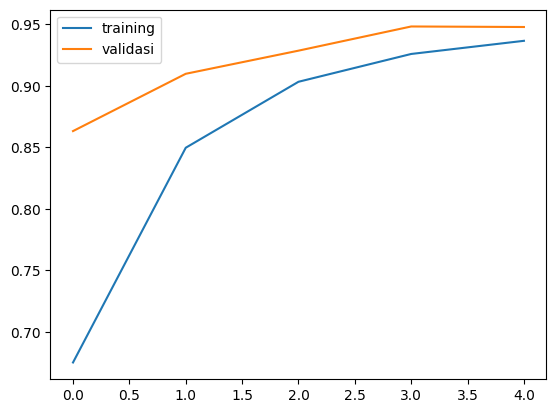

In [63]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='training')
plt.plot(history.history['val_accuracy'], label='validasi')
plt.legend()
plt.show()

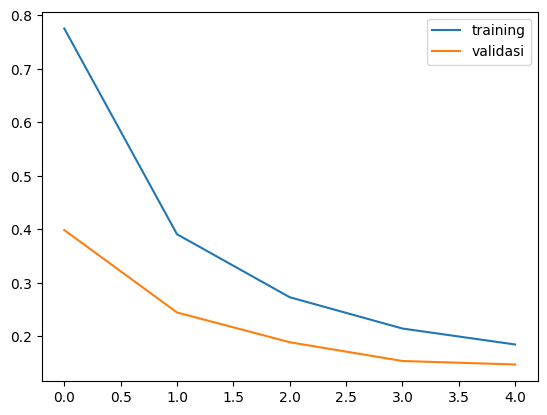

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validasi')
plt.legend()
plt.show()

# 8. Random Forest Model TF-IDF Cross Validation

**Ekstraksi Fitur TF-IDF**

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=10, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [66]:
df_tfidf_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

df_tfidf_features

,abai,abang,acara,accord,account,ada,adain,adakan,adik,adil,...,wilayah,wktu,worth,xjam,xl,yaaa,yah,yh,yng,youtube
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.274688,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
11993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [67]:
print(len(tfidf.get_feature_names_out()))

1698


# 9. Feature Selection

In [68]:
import numpy as np

x_train_tfidf = np.array(df_tfidf_features)
y_train_tfidf = np.array(y)

from sklearn.feature_selection import SelectKBest, chi2

select_tfidf = SelectKBest(chi2, k=1000)
text_tfidf_selected = select_tfidf.fit_transform(x_train_tfidf, y_train_tfidf)

print('Feature Number Asli', x_train_tfidf.shape[1])
print('Feature Number Pengurangan', text_tfidf_selected.shape[1])

Feature Number Asli 1698
Feature Number Pengurangan 1000


# 10. SMOTE Oversampling

In [69]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

oversampler_tfidf = SMOTE(random_state=2)
X_resampled_tfidf, y_resampled_tfidf = oversampler_tfidf.fit_resample(text_tfidf_selected, y_train_tfidf)

# 11. Melatih Model Random Forest dengan Pembagian Cross Validation

In [70]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=200)

In [71]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores_train = []
accuracy_scores_test = []
confusion_matrixes = []

for train_index, test_index in SKF.split(X_resampled_tfidf, y_resampled_tfidf):
    X_train_fold, X_test_fold = X_resampled_tfidf[train_index], X_resampled_tfidf[test_index]
    y_train_fold, y_test_fold = y_resampled_tfidf[train_index], y_resampled_tfidf[test_index]

    random_forest.fit(X_train_fold, y_train_fold)
    y_predict_train = random_forest.predict(X_train_fold)
    acc_train_score = accuracy_score(y_train_fold, y_predict_train)
    accuracy_scores_train.append(acc_train_score)

    y_predict_test = random_forest.predict(X_test_fold)

    confusionn_matrix = confusion_matrix(y_test_fold, y_predict_test)
    confusion_matrixes.append(confusionn_matrix)

    acc_test_score = accuracy_score(y_test_fold, y_predict_test)
    accuracy_scores_test.append(acc_test_score)

for i, (confusionn_matrix, acc_train, acc_test) in enumerate(zip(confusion_matrixes, accuracy_scores_train, accuracy_scores_test), 1):
    print(f'Fold {i}:')
    print(f'Accuracy Train: {acc_train}')
    print(f'Accuracy Test: {acc_test}')
    print(f'Confusion Matrix:\n{confusionn_matrix}')

mean_acc_train_score = np.mean(accuracy_scores_train)
mean_acc_test_score = np.mean(accuracy_scores_test)

print(f'Mean Accuracy Train: {mean_acc_train_score}')
print(f'Mean Accuracy Test: {mean_acc_test_score}')

Fold 1:
Accuracy Train: 0.9993346956232476
Accuracy Test: 0.9115006412997008
Confusion Matrix:
[[668  22  90]
 [  1 772   6]
 [ 79   9 692]]
Fold 2:
Accuracy Train: 0.9994297391056408
Accuracy Test: 0.9191962377084224
Confusion Matrix:
[[679  20  81]
 [  1 773   5]
 [ 68  14 698]]
Fold 3:
Accuracy Train: 0.9993822467211557
Accuracy Test: 0.9157399486740804
Confusion Matrix:
[[676  18  85]
 [  2 767  10]
 [ 74   8 698]]
Fold 4:
Accuracy Train: 0.9995248051701198
Accuracy Test: 0.8999144568006844
Confusion Matrix:
[[652  19 108]
 [  3 770   6]
 [ 83  15 682]]
Fold 5:
Accuracy Train: 0.9993822467211557
Accuracy Test: 0.9148845166809239
Confusion Matrix:
[[655  17 107]
 [  1 774   5]
 [ 63   6 710]]
Fold 6:
Accuracy Train: 0.9993822467211557
Accuracy Test: 0.9234388366124893
Confusion Matrix:
[[674  11  94]
 [  0 778   2]
 [ 66   6 707]]
Fold 7:
Accuracy Train: 0.9993822467211557
Accuracy Test: 0.9251497005988024
Confusion Matrix:
[[672  14  93]
 [  0 777   3]
 [ 56   9 714]]
Fold 8:
Accur

In [72]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, classification_report

SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

confusion_matrixes = []
accuracy_scores = []
balanced_accuracy_scores = []

for train_index, test_index in SKF.split(X_resampled_tfidf, y_resampled_tfidf):
  X_train_fold, X_test_fold = X_resampled_tfidf[train_index], X_resampled_tfidf[test_index]
  y_train_fold, y_test_fold = y_resampled_tfidf[train_index], y_resampled_tfidf[test_index]

  random_forest.fit(X_train_fold, y_train_fold)

  y_predict_fold = random_forest.predict(X_test_fold)

  confusionn_matrix = confusion_matrix(y_test_fold, y_predict_fold)
  confusion_matrixes.append(confusionn_matrix)

  acc_score = accuracy_score(y_test_fold, y_predict_fold)
  ball_acc_score = balanced_accuracy_score(y_test_fold, y_predict_fold)
  accuracy_scores.append(acc_score)
  balanced_accuracy_scores.append(ball_acc_score)

for i, (confusionn_matrix, acc_score, ball_acc_score) in enumerate(zip(confusion_matrixes, accuracy_scores, balanced_accuracy_scores), 1):
  print(f'Fold {i}:')
  print(f'Accuracy: {acc_score}')
  print(f'Confusion Matrix:\n{confusionn_matrix}')

mean_acc_score = np.mean(accuracy_scores)
print(f'Mean Accuracy CV: {mean_acc_score}')

Fold 1:
Accuracy: 0.9166310389055152
Confusion Matrix:
[[672  21  87]
 [  2 773   4]
 [ 71  10 699]]
Fold 2:
Accuracy: 0.9174861051731509
Confusion Matrix:
[[679  20  81]
 [  1 772   6]
 [ 72  13 695]]
Fold 3:
Accuracy: 0.9161676646706587
Confusion Matrix:
[[677  18  84]
 [  2 766  11]
 [ 73   8 699]]
Fold 4:
Accuracy: 0.9063301967493584
Confusion Matrix:
[[652  20 107]
 [  3 773   3]
 [ 73  13 694]]
Fold 5:
Accuracy: 0.9161676646706587
Confusion Matrix:
[[661  16 102]
 [  1 774   5]
 [ 64   8 707]]
Fold 6:
Accuracy: 0.9234388366124893
Confusion Matrix:
[[674   9  96]
 [  0 777   3]
 [ 64   7 708]]
Fold 7:
Accuracy: 0.9247219846022241
Confusion Matrix:
[[672  14  93]
 [  0 777   3]
 [ 59   7 713]]
Fold 8:
Accuracy: 0.913601368691189
Confusion Matrix:
[[669  17  93]
 [  1 775   4]
 [ 72  15 692]]
Fold 9:
Accuracy: 0.9144568006843456
Confusion Matrix:
[[661  17 102]
 [  0 777   2]
 [ 70   9 700]]
Fold 10:
Accuracy: 0.9054747647562019
Confusion Matrix:
[[659  26  95]
 [  3 773   3]
 [ 84 

# 12. RNN Model GRU dengan Tokenizer Keras

**Oversampling Class Imbalance**

In [73]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)
X_resampled_gru, y_resampled_gru = oversampler.fit_resample(X.values.reshape(-1, 1), y)

In [74]:
df_resampled  = pd.DataFrame(X_resampled_gru, columns=['text'])
df_resampled['polarity'] = y_resampled_gru

**Data Splitting**

In [75]:
df_resampled['word_lenght'] = df_resampled['text'].str.split()
df_resampled['word_lenght'] = df_resampled['word_lenght'].str.len()
df_resampled.dropna(inplace=True)

In [76]:
df_resampled.head(10)

,text,polarity,word_lenght
0,aplikasi gojek lamalama bikin nyamanudah vouch...,positive,24
1,mesan sengaja batal cancel pesan tekan tombol ...,positive,30
2,pengunaan transportasi oketapi tunggu harga st...,positive,26
3,aplikasi bantu pergi pesan makan cepat drivern...,positive,20
4,beli minum aplikasi harga mahal lupa voucher h...,positive,25
5,tolong driver gocarnya seleksi ramah tumpang k...,positive,27
6,driver dlm menit order gofood otomatis cancel ...,neutral,31
7,kecewa bayar gopaylater tahun curiga blokir go...,negative,19
8,fitur langgan gojek plus bagus gojek plus mili...,positive,31
9,kali kasih rating app lamaaaaa pakai si ganti ...,negative,32


In [77]:
df_resampled['word_lenght'].sort_values(ascending=False)

,word_lenght
8630,89
10628,68
11603,68
2380,63
7325,63
...,...
18261,0
16345,0
22167,0
22098,0


In [78]:
from sklearn.model_selection import train_test_split

X_train_gru, X_test_gru, y_train_gru, y_test_gru = train_test_split(df_resampled['text'], df_resampled['polarity'], test_size=0.1, random_state=42)

# 13. Pre-Processing Text dengan Tokenizer Keras

In [79]:
!pip install tensorflow
!pip install keras
from tensorflow.keras.preprocessing.text import Tokenizer

max_len = 200
trunc_type = 'post'
padding_type = 'post'
oov_tok = ''
vocab_size = 2000

tokenizer = Tokenizer(num_words = vocab_size, char_level=False, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_gru)

In [80]:
word_index = tokenizer.word_index
total_words = len(word_index)
total_words

17165

In [81]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequences_train_gru = tokenizer.texts_to_sequences(X_train_gru)
padded_train_gru = pad_sequences(sequences_train_gru, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [82]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequences_validation = tokenizer.texts_to_sequences(X_test_gru)
padded_validation = pad_sequences(sequences_validation, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [83]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_train_gru_encoded = label_encoder.fit_transform(y_train_gru)
y_train_gru_one_hot = to_categorical(y_train_gru_encoded)

y_test_gru_encoded = label_encoder.transform(y_test_gru)
y_test_gru_one_hot = to_categorical(y_test_gru_encoded)

print("Mapping Nilai Encode:")
for label, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
  print(f"{label}: {encoded_value}")

Mapping Nilai Encode:
negative: 0
neutral: 1
positive: 2


In [84]:
print('Train tensor:', padded_train_gru.shape)
print('Test tensor:', padded_validation.shape)

Train tensor: (21043, 200)
Test tensor: (2339, 200)


# 14. GRU

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D, Bidirectional

embedding_dim = 128
drop_value = 0.2

gru_model = Sequential()
gru_model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length=max_len))
gru_model.add(GRU(64, return_sequences=True))
gru_model.add(GlobalAveragePooling1D())
gru_model.add(Dense(24, activation='relu'))
gru_model.add(Dropout(drop_value))
gru_model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [87]:
gru_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [88]:
import tensorflow as tf
from keras.callbacks import EarlyStopping

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.93 and logs.get('val_accuracy') > 0.93:
            print("\nAkurasi train dan test telah mencapai >93%! Train dihentikan.")
            self.model.stop_training = True
callbacks = myCallback()
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [89]:
history1 = gru_model.fit(padded_train_gru,
                    y_train_gru_one_hot,
                    epochs = 50,
                    batch_size = 32,
                    validation_data = (padded_validation, y_test_gru_one_hot),
                    callbacks = [early_stop, callbacks],
                    verbose=2)

Epoch 1/50
658/658 - 14s - 21ms/step - accuracy: 0.4485 - loss: 1.0093 - val_accuracy: 0.6003 - val_loss: 0.7982
Epoch 2/50
658/658 - 8s - 11ms/step - accuracy: 0.7887 - loss: 0.5061 - val_accuracy: 0.9021 - val_loss: 0.2768
Epoch 3/50

Akurasi train dan test telah mencapai >93%! Train dihentikan.
658/658 - 18s - 27ms/step - accuracy: 0.9345 - loss: 0.1893 - val_accuracy: 0.9508 - val_loss: 0.1472


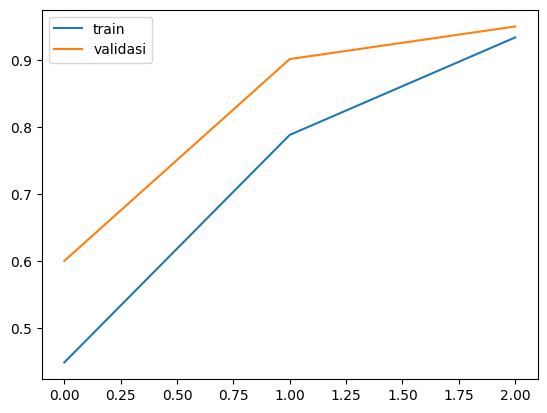

In [90]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'], label='train')
plt.plot(history1.history['val_accuracy'], label='validasi')
plt.legend()
plt.show()

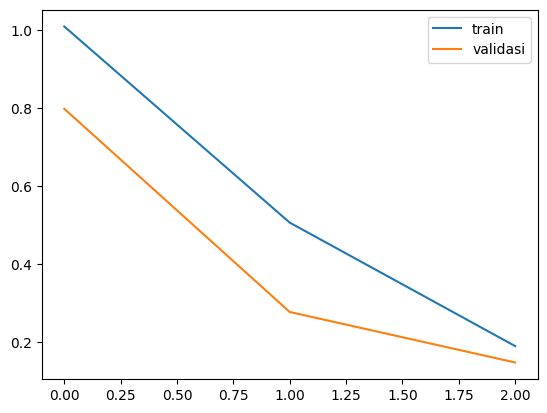

In [91]:
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='validasi')
plt.legend()
plt.show()

# 15. Perbandingan 3 Percobaan Test dari 3 Model, 2 Ekstraksi Fitur, 2 Data Split yang Berbeda

In [92]:
import numpy as np

# Model GRU
gru_train = gru_model.evaluate(padded_train_gru, np.asarray(y_train_gru_one_hot), verbose=2, batch_size=32)
gru_test = gru_model.evaluate(padded_validation, np.asarray(y_test_gru_one_hot), verbose=2, batch_size=32)

# Model ANN
ann_train = ann_model.evaluate(X_train_tfidf, np.asarray(Y_train_tfidf_one_hot), verbose=2, batch_size=32)
ann_test = ann_model.evaluate(X_test_tfidf, np.asarray(Y_test_tfidf_one_hot), verbose=2, batch_size=32)

mean_train_acc_score = np.mean(accuracy_scores_train)
mean_test_acc_score = np.mean(accuracy_scores_test)

print()
print(f'Accuracy Train Mean Random Forest : {mean_train_acc_score*100:0.2f} Mean Test Accuracy RF : {mean_test_acc_score*100:0.2f}')
print(f'Accuracy Train GRU : {gru_train[1]*100:0.2f} Test Accuracy GRU : {gru_test[1]*100:0.2f}')
print(f'Accuracy Train ANN : {ann_train[1]*100:0.2f} Test Accuracy ANN : {ann_test[1]*100:0.2f}')

658/658 - 4s - 6ms/step - accuracy: 0.9687 - loss: 0.0975
74/74 - 1s - 9ms/step - accuracy: 0.9508 - loss: 0.1472
658/658 - 2s - 3ms/step - accuracy: 0.9845 - loss: 0.0638
74/74 - 0s - 3ms/step - accuracy: 0.9478 - loss: 0.1475

Accuracy Train Mean Random Forest : 99.94 Mean Test Accuracy RF : 91.42
Accuracy Train GRU : 96.87 Test Accuracy GRU : 95.08
Accuracy Train ANN : 98.45 Test Accuracy ANN : 94.78


# 16. Testing

In [93]:
new_kalimat = input("Masukkan kalimat baru: ")

new_kalimat_cleaned = cleaningText(new_kalimat)
new_kalimat_casefolded = casefoldingText(new_kalimat_cleaned)
new_kalimat_slangfixed = fix_slangwords(new_kalimat_casefolded)
new_kalimat_tokenized = tokenizingText(new_kalimat_slangfixed)
new_kalimat_filtered = filteringText(new_kalimat_tokenized)
new_kalimat_akhir = toSentence(new_kalimat_filtered)

X_new_kalimat = tfidf.transform([new_kalimat_akhir])

X_new_kalimat = pd.DataFrame(X_new_kalimat.toarray(), columns=tfidf.get_feature_names_out())

new = np.array(X_new_kalimat)

selector = select_tfidf.transform(new)

new_prediksi = random_forest.predict(selector)

predicted_index = np.argmax(new_prediksi)

if predicted_index == 0:
    print("Sentimen kalimat baru adalah baru adalah POSITIVE.")
elif predicted_index == 1:
    print("Sentimen kalimat baru adalah NEUTRAL.")
else:
    print("Sentimen kalimat baru adalah NEGATIVE.")

Masukkan kalimat baru: aman naik gojek
Sentimen kalimat baru adalah baru adalah POSITIVE.


In [94]:
!pip freeze > requirement.txt